In [1]:
"""
!pip install shap -q
"""

import shap
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from google.colab import drive
import warnings
warnings.filterwarnings('ignore')

print(f"SHAP version: {shap.__version__}")
print("✅ All libraries loaded")


SHAP version: 0.52.0
✅ All libraries loaded


In [3]:
# CELL 2 — Mount Google Drive & Define Paths
# ─────────────────────────────────────────────────────────────────────────────
# WHY: All saved artifacts (model, features, data) live in Drive.
# We define one base path so every file reference is consistent.
# IMPORTANT: Mount Drive ONCE per session; re-running won't hurt.

drive.mount('/content/drive')

BASE = '/content/drive/MyDrive/financial-news-sentiment-stock-predictor'

PATHS = {
    'model':        f'{BASE}/models/xgboost_model.pkl',
    'feature_cols': f'{BASE}/models/feature_cols.pkl',
    'best_params':  f'{BASE}/models/best_params.pkl',
    'data':         f'{BASE}/data/features_combined.csv',
    'plots':        f'{BASE}/plots',
}

print("✅ Drive mounted. Paths configured:")
for k, v in PATHS.items():
    print(f"   {k}: {v}")

Mounted at /content/drive
✅ Drive mounted. Paths configured:
   model: /content/drive/MyDrive/financial-news-sentiment-stock-predictor/models/xgboost_model.pkl
   feature_cols: /content/drive/MyDrive/financial-news-sentiment-stock-predictor/models/feature_cols.pkl
   best_params: /content/drive/MyDrive/financial-news-sentiment-stock-predictor/models/best_params.pkl
   data: /content/drive/MyDrive/financial-news-sentiment-stock-predictor/data/features_combined.csv
   plots: /content/drive/MyDrive/financial-news-sentiment-stock-predictor/plots


In [4]:
# CELL 3 — Load Saved Model Artifacts
# ─────────────────────────────────────────────────────────────────────────────
# WHY: We load the exact same model and feature list saved in Phase 5.
# Using pickle.load ensures we don't retrain — we explain the trained model.
# best_params are loaded for reference / display purposes.

with open(PATHS['model'], 'rb') as f:
    model = pickle.load(f)

with open(PATHS['feature_cols'], 'rb') as f:
    feature_cols = pickle.load(f)

with open(PATHS['best_params'], 'rb') as f:
    best_params = pickle.load(f)

print(f"✅ Model loaded:  {type(model).__name__}")
print(f"✅ Features ({len(feature_cols)}): {feature_cols}")
print(f"\nBest hyperparameters used:")
for k, v in best_params.items():
    print(f"   {k}: {v}")

✅ Model loaded:  XGBClassifier
✅ Features (15): ['close_to_sma20', 'close_to_sma50', 'rsi_14', 'rsi_from_70', 'rsi_from_30', 'macd', 'macd_signal', 'macd_diff', 'bb_width', 'bb_position', 'daily_return', 'volatility_10', 'volume_change', 'volume_ratio', 'ticker_encoded']

Best hyperparameters used:
   subsample: 0.7
   reg_lambda: 0.5
   reg_alpha: 0
   n_estimators: 100
   min_child_weight: 7
   max_depth: 3
   learning_rate: 0.01
   gamma: 0
   colsample_bytree: 0.6


In [5]:
# CELL 4 — Load Data & Prepare Feature Matrix
# ─────────────────────────────────────────────────────────────────────────────
# WHY: SHAP needs the same X matrix the model was trained on.
# We reload features_combined.csv, drop non-feature columns, and keep
# only feature_cols — the 15 technical features the final model uses.
# We also sort by Date to maintain temporal order for later per-period analysis.

df = pd.read_csv(PATHS['data'], parse_dates=['Date'])
df = df.sort_values(['Date', 'ticker']).reset_index(drop=True)

# Separate feature matrix and target
X = df[feature_cols].copy()
y = df['target'].copy()

print(f"✅ Data loaded: {df.shape}")
print(f"   Feature matrix X: {X.shape}")
print(f"   Target y: {y.shape} | Up: {y.mean():.1%} | Down: {(1-y.mean()):.1%}")
print(f"\nSample of X:")
print(X.head(3))


✅ Data loaded: (6030, 28)
   Feature matrix X: (6030, 15)
   Target y: (6030,) | Up: 52.1% | Down: 47.9%

Sample of X:
   close_to_sma20  close_to_sma50     rsi_14  rsi_from_70  rsi_from_30  \
0        1.017625        1.050178  60.407454    -9.592546    30.407454   
1        0.976264        0.941381  38.204455   -31.795545     8.204455   
2        1.027982        1.082150  69.772132    -0.227868    39.772132   

       macd  macd_signal  macd_diff  bb_width  bb_position  daily_return  \
0  1.519520     1.708888  -0.189368  0.047673     0.869717      0.010257   
1 -4.036137    -3.579196  -0.456941  0.151418     0.343243      0.020600   
2  2.309155     2.495124  -0.185969  0.046569     1.100875      0.019006   

   volatility_10  volume_change  volume_ratio  ticker_encoded  
0       0.012779      -0.006900      0.845126               0  
1       0.010540      -0.026888      0.944767               1  
2       0.009379      -0.087837      1.059088               2  


In [6]:
# CELL 5 — Create SHAP TreeExplainer & Compute SHAP Values
# ─────────────────────────────────────────────────────────────────────────────
# WHY: TreeExplainer is SHAP's fastest, most exact algorithm for tree-based
# models (XGBoost, LightGBM, Random Forest). It computes Shapley values —
# the fair contribution of each feature to each individual prediction.
# We compute on the FULL 6,030 rows for global feature importance.
# shap_values[:,1] = SHAP values for class 1 (UP prediction).

explainer = shap.TreeExplainer(model)
print("⏳ Computing SHAP values on all 6,030 rows... (takes ~30-60 seconds)")

shap_values = explainer.shap_values(X)

# For binary XGBoost, shap_values is shape (n_samples, n_features)
# Positive SHAP → pushes toward class 1 (UP), negative → toward class 0 (DOWN)
print(f"✅ SHAP values computed: {shap_values.shape}")
print(f"   Shape: (rows={shap_values.shape[0]}, features={shap_values.shape[1]})")
print(f"   Mean |SHAP| per feature (top 5):")
mean_abs_shap = np.abs(shap_values).mean(axis=0)
top5_idx = np.argsort(mean_abs_shap)[::-1][:5]
for i in top5_idx:
    print(f"      {feature_cols[i]}: {mean_abs_shap[i]:.4f}")

⏳ Computing SHAP values on all 6,030 rows... (takes ~30-60 seconds)
✅ SHAP values computed: (6030, 15)
   Shape: (rows=6030, features=15)
   Mean |SHAP| per feature (top 5):
      volume_change: 0.0171
      close_to_sma50: 0.0147
      volume_ratio: 0.0132
      macd_diff: 0.0115
      bb_width: 0.0113


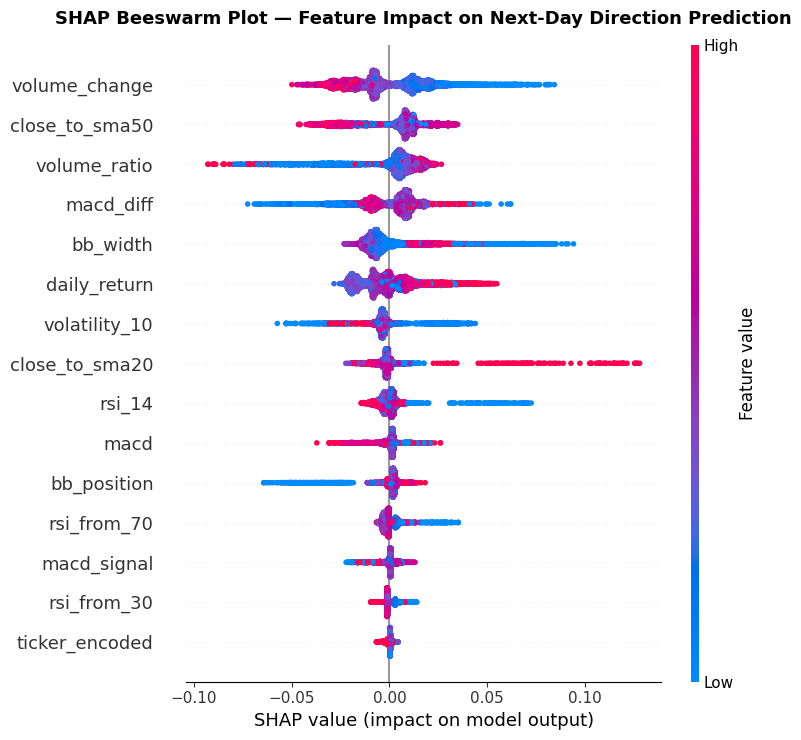

✅ Saved: shap_beeswarm.png


In [7]:
# CELL 6 — SHAP Summary Plot (Beeswarm) — Global Feature Importance
# ─────────────────────────────────────────────────────────────────────────────
# WHY: The beeswarm plot shows ALL 6,030 SHAP values per feature.
# Each dot = one row. Color = feature value (red=high, blue=low).
# X-axis position = SHAP value = how much that feature pushed the
# prediction toward UP (+) or DOWN (-). This is the signature SHAP viz.

plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values, X,
    feature_names=feature_cols,
    plot_type="dot",      # beeswarm
    max_display=15,       # show all 15 features
    show=False
)
plt.title("SHAP Beeswarm Plot — Feature Impact on Next-Day Direction Prediction",
          fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig(f"{PATHS['plots']}/shap_beeswarm.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: shap_beeswarm.png")

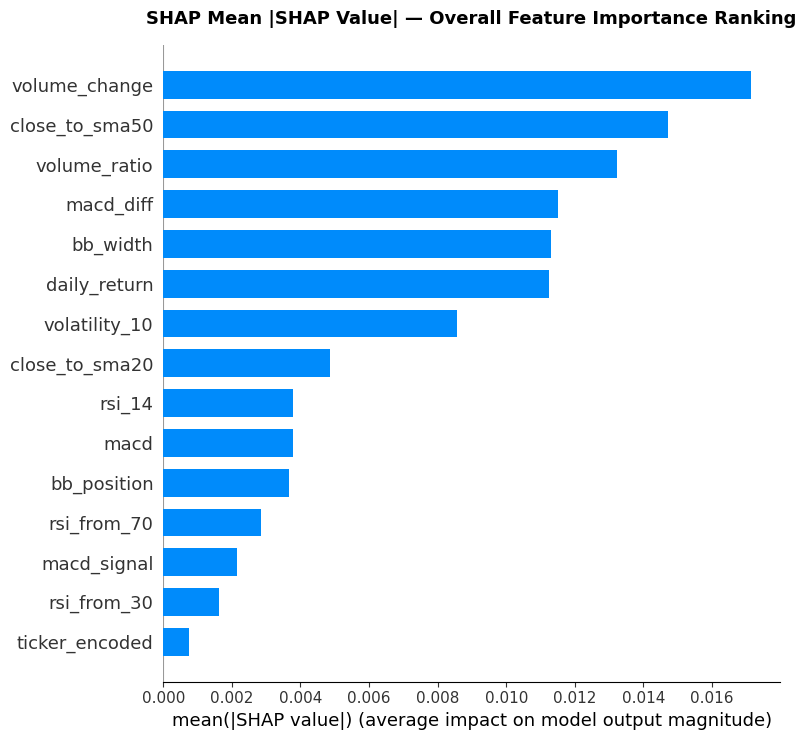

✅ Saved: shap_bar.png


In [9]:
 # CELL 7 — SHAP Bar Plot — Mean Absolute Feature Importance
# ─────────────────────────────────────────────────────────────────────────────
# WHY: The bar plot collapses each feature to its mean |SHAP| across all rows.
# Easier to read than beeswarm for ranking. Good for README and portfolio.
# This is the "global importance" view — which features matter most overall.

plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values, X,
    feature_names=feature_cols,
    plot_type="bar",
    max_display=15,
    show=False
)
plt.title("SHAP Mean |SHAP Value| — Overall Feature Importance Ranking",
          fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig(f"{PATHS['plots']}/shap_bar.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: shap_bar.png")

Top 3 features by mean |SHAP|: ['volume_change', 'close_to_sma50', 'volume_ratio']


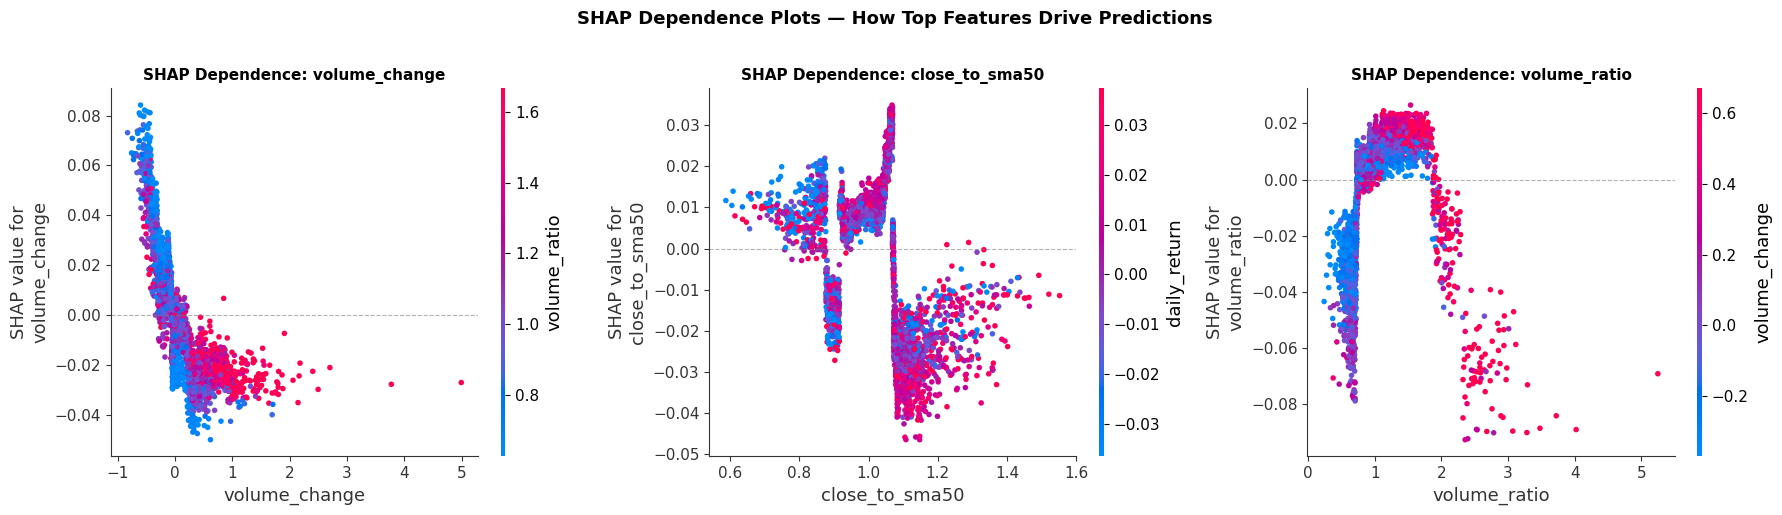

✅ Saved: shap_dependence_top3.png


In [10]:
# CELL 8 — SHAP Dependence Plots (Top 3 Features)
# ─────────────────────────────────────────────────────────────────────────────
# WHY: Dependence plots show how a single feature's value (X-axis) affects
# its SHAP contribution (Y-axis). The color encodes the most interacting
# feature. This reveals the non-linear relationship XGBoost learned.
# We plot the top 3 features by mean |SHAP| for interview storytelling.

mean_abs = pd.Series(np.abs(shap_values).mean(axis=0), index=feature_cols)
top3_features = mean_abs.nlargest(3).index.tolist()
print(f"Top 3 features by mean |SHAP|: {top3_features}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, feat in zip(axes, top3_features):
    shap.dependence_plot(
        feat, shap_values, X,
        feature_names=feature_cols,
        ax=ax,
        show=False
    )
    ax.set_title(f"SHAP Dependence: {feat}", fontsize=11, fontweight='bold')
    ax.axhline(0, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)

plt.suptitle("SHAP Dependence Plots — How Top Features Drive Predictions",
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f"{PATHS['plots']}/shap_dependence_top3.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: shap_dependence_top3.png")

Selected prediction examples:
  Confident UP: Date=2023-02-02, Ticker=TSLA, P(UP)=0.586, Actual=UP
  Confident DOWN: Date=2025-12-16, Ticker=GOOGL, P(UP)=0.463, Actual=DOWN
  Borderline: Date=2024-12-27, Ticker=AMZN, P(UP)=0.500, Actual=DOWN


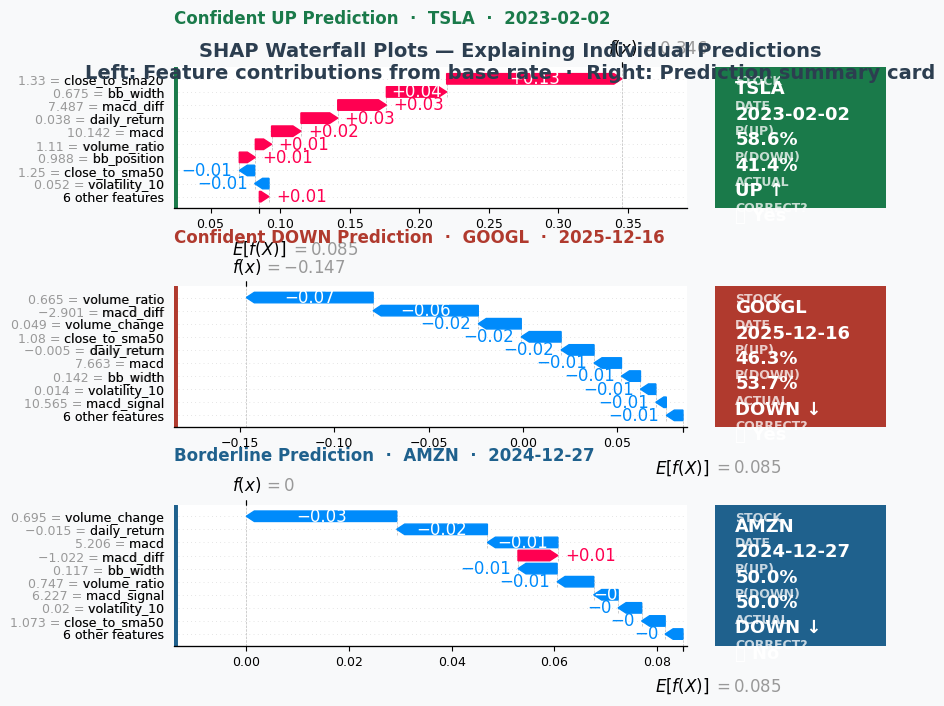

✅ Saved: shap_waterfall_3cases.png


In [19]:
# CELL 9 — SHAP Waterfall Plots (3 Individual Predictions in 3×2 Grid)
# ─────────────────────────────────────────────────────────────────────────────
# WHY: Waterfall plots explain ONE prediction at a time — the local view.
# They show how each feature pushed the prediction UP or DOWN from the
# expected base value. We pick 3 rows: one confident UP, one confident DOWN,
# one borderline case — and display each with a title + info panel beside it.

import math

# Compute model predicted probabilities for selecting interesting rows
probs = model.predict_proba(X)[:, 1]   # P(UP) for all 6030 rows

# Find 3 interesting examples
idx_confident_up   = np.argmax(probs)                # highest P(UP)
idx_confident_down = np.argmin(probs)                # lowest P(UP)
idx_borderline     = np.argmin(np.abs(probs - 0.5)) # closest to 50/50

print("Selected prediction examples:")
for label, idx in [("Confident UP",   idx_confident_up),
                   ("Confident DOWN",  idx_confident_down),
                   ("Borderline",      idx_borderline)]:
    row = df.iloc[idx]
    print(f"  {label}: Date={row['Date'].date()}, Ticker={row['ticker']}, "
          f"P(UP)={probs[idx]:.3f}, Actual={'UP' if y.iloc[idx]==1 else 'DOWN'}")

# Base value — handle both scalar and array output from TreeExplainer
base_value = explainer.expected_value
if isinstance(base_value, (list, np.ndarray)):
    base_value = float(base_value)

# ── 3×2 Grid Layout ───────────────────────────────────────────────────────────
# Left column  (col 0): SHAP waterfall plot
# Right column (col 1): clean info card summarising the prediction
# Row 0 → Confident UP | Row 1 → Confident DOWN | Row 2 → Borderline

cases = [
    ("Confident UP Prediction",   idx_confident_up,   "#1a7a4a"),  # green accent
    ("Confident DOWN Prediction", idx_confident_down, "#b03a2e"),  # red accent
    ("Borderline Prediction",     idx_borderline,     "#1f618d"),  # blue accent
]

fig = plt.figure(figsize=(22, 21))
fig.patch.set_facecolor('#f8f9fa')

# Build GridSpec: 3 rows × 2 columns
# Left column 70% width for waterfall, right column 30% for info card
gs = fig.add_gridspec(
    nrows=3, ncols=2,
    width_ratios=[3, 1],     # waterfall : info card = 3 : 1
    hspace=0.55,             # vertical gap between rows
    wspace=0.08,             # horizontal gap between columns
    left=0.08, right=0.97,
    top=0.93, bottom=0.04
)

for row_i, (label, idx, accent_color) in enumerate(cases):

    sample     = df.iloc[idx]
    actual_dir = "UP ↑" if y.iloc[idx] == 1 else "DOWN ↓"
    ticker     = sample['ticker']
    date_str   = sample['Date'].date()
    p_up       = probs[idx]
    p_down     = 1 - p_up

    # ── Left cell: SHAP waterfall ──────────────────────────────────
    ax_shap = fig.add_subplot(gs[row_i, 0])
    ax_shap.set_facecolor('white')

    explanation = shap.Explanation(
        values        = shap_values[idx],
        base_values   = base_value,
        data          = X.iloc[idx].values,
        feature_names = feature_cols
    )
    plt.sca(ax_shap)
    shap.plots.waterfall(explanation, max_display=10, show=False)

    # Accent bar on left edge of the waterfall subplot
    ax_shap.axvline(x=ax_shap.get_xlim()[0], color=accent_color,
                    linewidth=5, solid_capstyle='round')

    ax_shap.set_title(
        f"{label}  ·  {ticker}  ·  {date_str}",
        fontsize=12, fontweight='bold', color=accent_color,
        pad=10, loc='left'
    )
    ax_shap.tick_params(labelsize=9)

    # ── Right cell: Info card ──────────────────────────────────────
    ax_info = fig.add_subplot(gs[row_i, 1])
    ax_info.set_facecolor(accent_color)
    ax_info.set_xticks([])
    ax_info.set_yticks([])
    for spine in ax_info.spines.values():
        spine.set_visible(False)

    # Info text content
    lines = [
        ("STOCK",     ticker),
        ("DATE",      str(date_str)),
        ("P(UP)",     f"{p_up:.1%}"),
        ("P(DOWN)",   f"{p_down:.1%}"),
        ("ACTUAL",    actual_dir),
        ("CORRECT?",  "✅ Yes" if (
            (p_up >= 0.5 and y.iloc[idx] == 1) or
            (p_up < 0.5  and y.iloc[idx] == 0)
        ) else "❌ No"),
    ]

    y_pos = 0.88
    for key, val in lines:
        ax_info.text(0.12, y_pos, key,
                     transform=ax_info.transAxes,
                     fontsize=9, fontweight='bold',
                     color='white', alpha=0.75)
        ax_info.text(0.12, y_pos - 0.07, val,
                     transform=ax_info.transAxes,
                     fontsize=13, fontweight='bold', color='white')
        y_pos -= 0.18

# Overall title
fig.suptitle(
    "SHAP Waterfall Plots — Explaining Individual Predictions\n"
    "Left: Feature contributions from base rate  ·  "
    "Right: Prediction summary card",
    fontsize=14, fontweight='bold', color='#2c3e50', y=0.97
)

save_path = f"{PATHS['plots']}/shap_waterfall_3cases.png"
plt.savefig(save_path, dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print(f"✅ Saved: shap_waterfall_3cases.png")

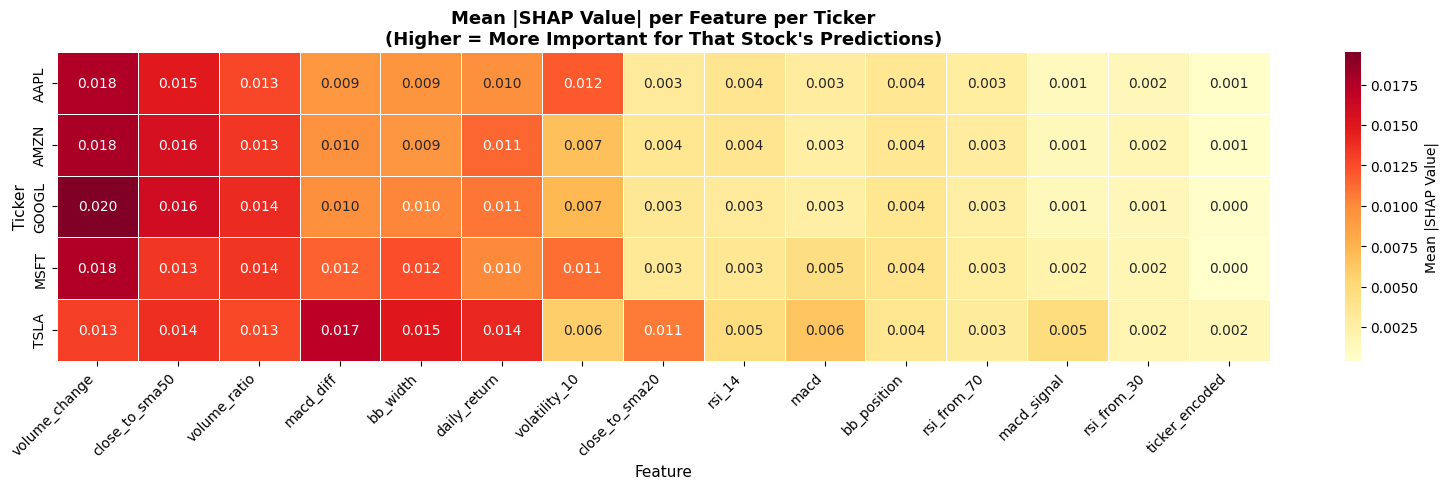

✅ Saved: shap_ticker_heatmap.png


In [12]:
# CELL 10 — Per-Ticker SHAP Importance Heatmap
# ─────────────────────────────────────────────────────────────────────────────
# WHY: Different stocks may rely on different features. TSLA (high volatility)
# might be driven more by volatility_10, while MSFT might lean on MACD.
# This heatmap shows mean |SHAP| per feature per ticker — a unique viz
# that demonstrates depth of analysis beyond a single global importance chart.

tickers = ['AAPL', 'AMZN', 'GOOGL', 'MSFT', 'TSLA']
shap_df = pd.DataFrame(shap_values, columns=feature_cols)
shap_df['ticker'] = df['ticker'].values

ticker_shap = {}
for ticker in tickers:
    mask = shap_df['ticker'] == ticker
    ticker_shap[ticker] = shap_df.loc[mask, feature_cols].abs().mean()

heatmap_df = pd.DataFrame(ticker_shap).T  # rows=tickers, cols=features

# Sort features by overall importance for readability
col_order = mean_abs.sort_values(ascending=False).index.tolist()
heatmap_df = heatmap_df[col_order]

plt.figure(figsize=(16, 5))
sns.heatmap(
    heatmap_df,
    annot=True, fmt='.3f',
    cmap='YlOrRd',
    linewidths=0.5,
    cbar_kws={'label': 'Mean |SHAP Value|'}
)
plt.title("Mean |SHAP Value| per Feature per Ticker\n(Higher = More Important for That Stock's Predictions)",
          fontsize=13, fontweight='bold')
plt.xlabel("Feature", fontsize=11)
plt.ylabel("Ticker", fontsize=11)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(f"{PATHS['plots']}/shap_ticker_heatmap.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: shap_ticker_heatmap.png")

In [15]:
 # CELL 11 — SHAP Direction Analysis (What Pushes UP vs DOWN)
# ─────────────────────────────────────────────────────────────────────────────
# WHY: We want to understand the directionality — not just which features
# matter, but HOW they push predictions. Positive mean SHAP when feature
# is above median → high values of this feature push toward UP predictions.
# This is a concise narrative for the interview: "When RSI is high, it..."

print("=" * 65)
print("SHAP DIRECTION ANALYSIS — Feature Impact on UP Prediction")
print("=" * 65)
print(f"{'Feature':<20} {'Mean SHAP':>12} {'Interpretation'}")
print("-" * 65)

mean_shap_signed = pd.Series(shap_values.mean(axis=0), index=feature_cols)

for feat in mean_abs.sort_values(ascending=False).index:
    signed = mean_shap_signed[feat]
    direction = "↑ Pushes UP" if signed > 0 else "↓ Pushes DOWN"
    print(f"{feat:<20} {signed:>+12.4f}  {direction}")

print("\n📌 Note: Signed mean SHAP shows overall directional bias.")
print("   Individual predictions vary; use beeswarm for per-row view.")

SHAP DIRECTION ANALYSIS — Feature Impact on UP Prediction
Feature                 Mean SHAP Interpretation
-----------------------------------------------------------------
volume_change             -0.0003  ↓ Pushes DOWN
close_to_sma50            +0.0010  ↑ Pushes UP
volume_ratio              +0.0004  ↑ Pushes UP
macd_diff                 +0.0006  ↑ Pushes UP
bb_width                  +0.0001  ↑ Pushes UP
daily_return              -0.0003  ↓ Pushes DOWN
volatility_10             +0.0001  ↑ Pushes UP
close_to_sma20            -0.0007  ↓ Pushes DOWN
rsi_14                    -0.0002  ↓ Pushes DOWN
macd                      -0.0004  ↓ Pushes DOWN
bb_position               +0.0001  ↑ Pushes UP
rsi_from_70               -0.0000  ↓ Pushes DOWN
macd_signal               -0.0001  ↓ Pushes DOWN
rsi_from_30               -0.0002  ↓ Pushes DOWN
ticker_encoded            +0.0000  ↑ Pushes UP

📌 Note: Signed mean SHAP shows overall directional bias.
   Individual predictions vary; use beeswarm for

In [17]:
 # CELL 12 — Save SHAP Values for Streamlit App
# ─────────────────────────────────────────────────────────────────────────────
# WHY: Phase 7 Streamlit app will need the SHAP explainer object to generate
# explanations for live predictions. We save the explainer (not values) so
# the app can call explainer.shap_values(new_X) on any new input row.
# We also save a ranked feature importance table for the app's display.

# Save explainer for Streamlit
with open(f'{BASE}/models/shap_explainer.pkl', 'wb') as f:
    pickle.dump(explainer, f)

# Save ranked feature importance as CSV (useful for app and README)
importance_df = pd.DataFrame({
    'feature': feature_cols,
    'mean_abs_shap': np.abs(shap_values).mean(axis=0),
    'mean_signed_shap': shap_values.mean(axis=0)
}).sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)

importance_df['rank'] = range(1, len(importance_df) + 1)
importance_df.to_csv(f'{BASE}/models/shap_feature_importance.csv', index=False)

print("✅ SHAP explainer saved: models/shap_explainer.pkl")
print("✅ Feature importance CSV saved: models/shap_feature_importance.csv")
print("\n📊 Final SHAP Feature Importance Ranking:")
print(importance_df[['rank', 'feature', 'mean_abs_shap', 'mean_signed_shap']].to_string(index=False))

✅ SHAP explainer saved: models/shap_explainer.pkl
✅ Feature importance CSV saved: models/shap_feature_importance.csv

📊 Final SHAP Feature Importance Ranking:
 rank        feature  mean_abs_shap  mean_signed_shap
    1  volume_change       0.017126         -0.000264
    2 close_to_sma50       0.014721          0.001046
    3   volume_ratio       0.013231          0.000401
    4      macd_diff       0.011496          0.000607
    5       bb_width       0.011293          0.000116
    6   daily_return       0.011243         -0.000269
    7  volatility_10       0.008561          0.000137
    8 close_to_sma20       0.004853         -0.000735
    9         rsi_14       0.003794         -0.000211
   10           macd       0.003789         -0.000403
   11    bb_position       0.003674          0.000062
   12    rsi_from_70       0.002848         -0.000001
   13    macd_signal       0.002142         -0.000132
   14    rsi_from_30       0.001636         -0.000213
   15 ticker_encoded       0.00

In [18]:
 # CELL 13 — Phase 6 Summary
# ─────────────────────────────────────────────────────────────────────────────
# WHY: A clean summary cell confirms what was accomplished and what's saved.
# This is the last thing to run before moving to Phase 7 locally.

print("=" * 60)
print("PHASE 6 COMPLETE — SHAP EXPLAINABILITY")
print("=" * 60)
print("\n✅ Plots saved to /plots/:")
print("   • shap_beeswarm.png          — Global beeswarm (all features, all rows)")
print("   • shap_bar.png               — Mean |SHAP| bar chart (ranked)")
print("   • shap_dependence_top3.png   — Dependence plots for top 3 features")
print("   • shap_waterfall_3cases.png  — Waterfall for 3 individual predictions")
print("   • shap_ticker_heatmap.png    — Per-ticker feature importance heatmap")
print("\n✅ Artifacts saved to /models/:")
print("   • shap_explainer.pkl         — SHAP explainer (for Streamlit app)")
print("   • shap_feature_importance.csv— Ranked importance table")
print("\n🎯 Key Findings:")
print(f"   Top feature by SHAP: {importance_df.iloc[0]['feature']}")
print(f"   All {len(feature_cols)} features contribute (none has zero SHAP)")
print("\n➡️  Next: Phase 7 — Streamlit App (build locally in VS Code)")

PHASE 6 COMPLETE — SHAP EXPLAINABILITY

✅ Plots saved to /plots/:
   • shap_beeswarm.png          — Global beeswarm (all features, all rows)
   • shap_bar.png               — Mean |SHAP| bar chart (ranked)
   • shap_dependence_top3.png   — Dependence plots for top 3 features
   • shap_waterfall_3cases.png  — Waterfall for 3 individual predictions
   • shap_ticker_heatmap.png    — Per-ticker feature importance heatmap

✅ Artifacts saved to /models/:
   • shap_explainer.pkl         — SHAP explainer (for Streamlit app)
   • shap_feature_importance.csv— Ranked importance table

🎯 Key Findings:
   Top feature by SHAP: volume_change
   All 15 features contribute (none has zero SHAP)

➡️  Next: Phase 7 — Streamlit App (build locally in VS Code)
